# Was a trained detector necessary?

The preceding notebooks establish that a single-target detector recovers impressions the
candidate-extraction stage never produced a region for. They do not establish that *training*
was required to reach them, and an evaluator is entitled to ask.

The obvious alternative needs no model at all. Normalised cross-correlation slides a known
image across a larger one and scores the match at every position; given a catalogue crop of a
fleuron, it will report where else that fleuron appears. It is the first thing anyone would
try, it has been standard since the 1970s, and on this corpus it costs no GPU and no labels
beyond the exemplars already in the catalogue.

This notebook compares the two against the same pre-recovery catalogue labels. Their scan
frames still differ, a limitation quantified below.

---

**Reads** frozen outputs of `_tools/template_matching_baseline.py` and
`_tools/leave_one_work_out.py` · **Writes** `4_detection_outputs/baseline_comparison/` ·
**Chapter README** §4.5

## 1. What a fair comparison requires

Three conditions, each of which was got wrong in a first attempt and corrected. They are
recorded because each one moves the result.

**The baseline must not see the work it is searching.** The detector is evaluated by
leave-one-work-out: for every scan, the model scoring it was trained without that scan's entire
work. A template drawn from a sibling volume of the book under search would give the baseline an
advantage the detector never had. Templates from the same work are therefore excluded.

**The baseline must not be given the answers.** The impressions the detector recovered were
folded into the catalogue afterwards. Drawing templates from the current catalogue would hand
the baseline the very crops it is supposed to find. Templates come from the catalogue snapshot
taken *before* the fold-in.

**Both methods must be scored against the same ground truth.** The detector's cross-validation
is scored against the catalogued impressions that existed at training time. The baseline was
initially scored against those *plus* the recovered ones, a harder set, which understated it.
The comparison below restricts both to the catalogued impressions, and reports performance on
the recovered impressions separately.

Two further points where the baseline is deliberately favoured rather than handicapped, so that
a negative result cannot be blamed on a weak implementation: each template is matched at seven
scales and in all four flip orientations, matching the flip augmentation the detector was
trained with, and the score threshold is swept rather than fixed, so the baseline is read off
its whole operating curve.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '4_detection', 'Run this notebook from its own folder, 4_detection/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
OUTPUTS = PROJECT_DIR/'4_detection_outputs'

RUN_TAG = ''
ALLOW_OVERWRITE = False
OUT = OUTPUTS/f'baseline_comparison{RUN_TAG}'

IOU_EVAL = 0.50      # the matching rule used throughout the chapter and in the extraction benchmark
DET_CONF = 0.25      # the detector's operating point, examined in notebook 3

INK, FOIL, RULE, FLAG = '#444444', '#b0b7bd', '#b23a3a', '#1f4e79'

TARGETS = ['Fleuron_2', 'Fleuron_74', 'Fleuron_73', 'Fleuron_72']
print('targets:', ', '.join(TARGETS))

targets: Fleuron_2, Fleuron_74, Fleuron_73, Fleuron_72


## 2. Scoring rule

One prediction may claim at most one ground-truth impression, taken in order of score, and a
claim counts only above IoU 0.50. This is the rule the candidate-extraction benchmark uses, so
the numbers here can be read against that chapter without translation.

In [2]:
def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union > 0 else 0.0


def score(pred, truth, score_col, threshold):
    """Greedy, score-ordered matching. Returns tp, fp, fn, precision, recall."""
    tp = fp = 0
    claimed = set()
    by_scan = {k: g for k, g in truth.groupby('stem')} if len(truth) else {}
    sel = pred[pred[score_col] >= threshold] if len(pred) else pred
    for r in (sel.sort_values(score_col, ascending=False).itertuples() if len(sel) else []):
        best, best_i = 0.0, None
        for g in by_scan.get(r.stem, pd.DataFrame()).itertuples():
            if g.Index in claimed:
                continue
            v = iou((r.x1, r.y1, r.x2, r.y2), (g.x1, g.y1, g.x2, g.y2))
            if v > best:
                best, best_i = v, g.Index
        if best >= IOU_EVAL:
            tp += 1
            claimed.add(best_i)
        else:
            fp += 1
    fn = len(truth) - tp
    return dict(tp=tp, fp=fp, fn=fn,
                precision=tp/(tp+fp) if tp+fp else 0.0,
                recall=tp/(tp+fn) if tp+fn else 0.0)

## 3. The comparison

For each target: the detector at its operating point, and the baseline across its threshold
sweep, both scored against the catalogued impressions that existed before the fold-in.

In [3]:
rows = []
for target in TARGETS:
    tm_dir = OUTPUTS/f'{target.lower()}_tm'
    lowo_dir = OUTPUTS/f'{target.lower()}_lowo'
    if not (tm_dir/'template_detections.csv').exists():
        print(f'{target}: no baseline run found, skipping')
        continue

    tm = pd.read_csv(tm_dir/'template_detections.csv')
    gt = pd.read_csv(tm_dir/'ground_truth.csv')
    catalogued = gt[gt.kind == 'catalogued'].reset_index(drop=True)
    recovered = gt[gt.kind == 'recovered'].reset_index(drop=True)

    # Both model sizes, and the spread over three seeds, so the baseline is compared against
    # a range rather than against one run of one configuration.
    for tag, label in [('_lowo', 'detector yolo11n'), ('_lowo_s', 'detector yolo11s')]:
        d = OUTPUTS/f'{target.lower()}{tag}'
        if not (d/'pooled_predictions.csv').exists():
            continue
        det = pd.read_csv(d/'pooled_predictions.csv')
        det_truth = pd.read_csv(d/'pooled_ground_truth.csv')
        s = score(det, det_truth, 'conf', DET_CONF)
        rows.append(dict(target=target, method=label, threshold=DET_CONF, **s,
                         recovered_found=np.nan, recovered_total=len(recovered)))

    seed_recalls = []
    for tag in ['_lowo', '_lowo_seed1', '_lowo_seed2']:
        d = OUTPUTS/f'{target.lower()}{tag}'
        if (d/'pooled_predictions.csv').exists():
            sp = score(pd.read_csv(d/'pooled_predictions.csv'),
                       pd.read_csv(d/'pooled_ground_truth.csv'), 'conf', DET_CONF)
            seed_recalls.append(sp['recall'])
    if seed_recalls:
        print(f'{target}: detector recall over {len(seed_recalls)} seeds '
              f'({min(seed_recalls):.3f} to {max(seed_recalls):.3f}) '
              f'-- differences smaller than this are not interpretable')

    for thr in [0.50, 0.60, 0.70, 0.80]:
        s = score(tm, catalogued, 'score', thr)
        r = score(tm, recovered, 'score', thr)
        rows.append(dict(target=target, method='template matching', threshold=thr, **s,
                         recovered_found=r['tp'], recovered_total=len(recovered)))

comparison = pd.DataFrame(rows)
comparison.to_csv('/tmp/_baseline_comparison_preview.csv', index=False)
for target, g in comparison.groupby('target', sort=False):
    print(f'\n{target}  (ground truth: {int(g.iloc[0].tp + g.iloc[0].fn)} catalogued impressions)')
    print(g[['method', 'threshold', 'precision', 'recall',
             'recovered_found', 'recovered_total']].round(3).to_string(index=False))

Fleuron_2: detector recall over 3 seeds (0.864 to 0.947) -- differences smaller than this are not interpretable


Fleuron_74: detector recall over 3 seeds (0.847 to 0.949) -- differences smaller than this are not interpretable


Fleuron_73: detector recall over 3 seeds (0.481 to 0.571) -- differences smaller than this are not interpretable


Fleuron_72: detector recall over 3 seeds (0.765 to 0.963) -- differences smaller than this are not interpretable



Fleuron_2  (ground truth: 265 catalogued impressions)
           method  threshold  precision  recall  recovered_found  recovered_total
 detector yolo11n       0.25      0.787   0.864              NaN               54
 detector yolo11s       0.25      0.711   0.947              NaN               54
template matching       0.50      0.040   0.834             38.0               54
template matching       0.60      0.441   0.800             32.0               54
template matching       0.70      0.830   0.774             31.0               54
template matching       0.80      0.872   0.592             19.0               54

Fleuron_74  (ground truth: 98 catalogued impressions)
           method  threshold  precision  recall  recovered_found  recovered_total
 detector yolo11n       0.25      0.544   0.949              NaN               33
 detector yolo11s       0.25      0.417   0.745              NaN               33
template matching       0.50      0.033   0.898             30.0      

## 4. Reading the result

Two questions are separate and should not be run together.

**Can the baseline reproduce the catalogue?** This is the precision and recall above, measured
on impressions both methods knew existed.

**Can the baseline reach what extraction never extracted?** This is the `recovered_found`
column: of the impressions the detector proposed and a reviewer confirmed, how many does
correlation also find. It is the question the chapter's claim rests on, and it is the one where
a training-free method has no prior advantage, since those impressions are by construction the
ones sitting in dense or damaged settings.

In [4]:
# The baseline's operating point is chosen by F2, matching the extraction benchmark's metric,
# rather than by whichever threshold maximises recall. Taking the highest-recall row would
# select a threshold whose precision is near zero and would flatter the baseline.
tm_all = comparison[comparison.method == 'template matching'].copy()
tm_all['f2'] = np.where(tm_all.precision + tm_all.recall > 0,
                        5*tm_all.precision*tm_all.recall/(4*tm_all.precision + tm_all.recall), 0.0)
best = tm_all.sort_values('f2', ascending=False).groupby('target', sort=False).head(1)
det = comparison[comparison.method.str.startswith('detector')]

summary = []
for target in comparison.target.unique():
    b = best[best.target == target].iloc[0]
    row = dict(target=target)
    for label, short in [('detector yolo11n', 'n'), ('detector yolo11s', 's')]:
        d = det[(det.target == target) & (det.method == label)]
        if len(d):
            row[f'det_{short}_P'] = round(d.iloc[0].precision, 3)
            row[f'det_{short}_R'] = round(d.iloc[0].recall, 3)
    row.update(baseline_P=round(b.precision, 3), baseline_R=round(b.recall, 3),
               baseline_threshold=b.threshold,
               recovered=f'{int(b.recovered_found)}/{int(b.recovered_total)}')
    summary.append(row)
summary = pd.DataFrame(summary)
print(summary.to_string(index=False))

    target  det_n_P  det_n_R  det_s_P  det_s_R  baseline_P  baseline_R  baseline_threshold recovered
 Fleuron_2    0.787    0.864    0.711    0.947       0.830       0.774                 0.7     31/54
Fleuron_74    0.544    0.949    0.417    0.745       0.776       0.459                 0.7     11/33
Fleuron_73    0.791    0.486    0.681    0.757       0.658       0.836                 0.6    79/121
Fleuron_72    0.734    0.827    0.511    0.978       0.658       0.850                 0.6   222/494


## 5. Figure

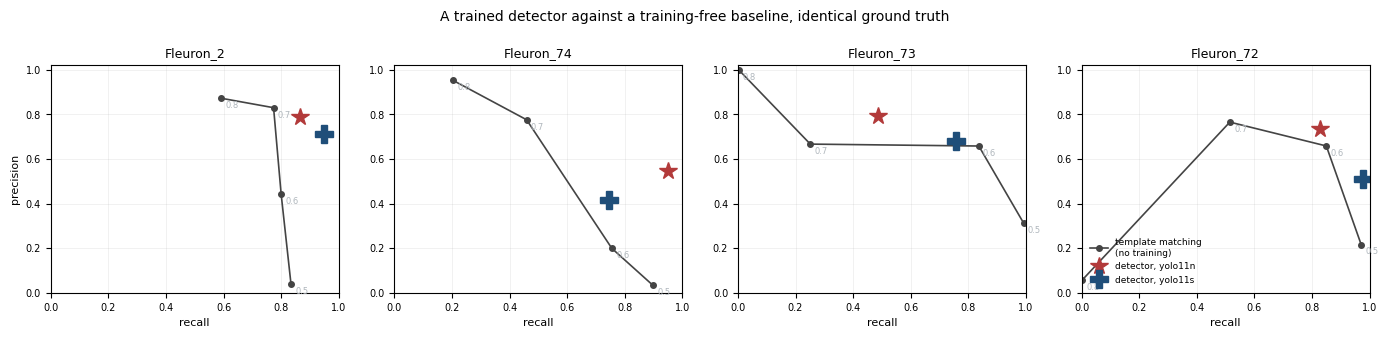

In [5]:
avail = comparison.target.unique()
fig, axes = plt.subplots(1, len(avail), figsize=(3.5*len(avail), 3.4), squeeze=False)
for ax, target in zip(axes[0], avail):
    g = comparison[comparison.target == target]
    tm = g[g.method == 'template matching'].sort_values('threshold')
    ax.plot(tm.recall, tm.precision, '-o', color=INK, ms=4, lw=1.2,
            label='template matching\n(no training)')
    for _, r in tm.iterrows():
        ax.annotate(f'{r.threshold:.1f}', (r.recall, r.precision), fontsize=6,
                    color=FOIL, xytext=(3, -7), textcoords='offset points')
    for label, colour, mark in [('detector yolo11n', RULE, '*'),
                                ('detector yolo11s', FLAG, 'P')]:
        dd = g[g.method == label]
        if len(dd):
            ax.plot([dd.iloc[0].recall], [dd.iloc[0].precision], mark, color=colour, ms=13,
                    label=label.replace('detector ', 'detector, '))
    ax.set_title(target, fontsize=9)
    ax.set_xlabel('recall', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25, lw=0.5)
axes[0][0].set_ylabel('precision', fontsize=8)
axes[0][-1].legend(fontsize=6.5, loc='lower left', frameon=False)
fig.suptitle('Same pre-recovery labels; different evaluation scan frames',
             fontsize=10)
fig.tight_layout()
plt.show()

## 6. Writing the result out

The comparison table and figure are written only when the run is complete for every target, so
a partial run cannot be mistaken for the reported one.

In [6]:
def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(
            f'{path} already contains results. Set RUN_TAG to write elsewhere, '
            f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)
    return path


if len(comparison.target.unique()) < len(TARGETS):
    print(f'{len(comparison.target.unique())} of {len(TARGETS)} targets present; '
          f'not writing a partial comparison.')
else:
    guarded_mkdir(OUT)
    comparison.to_csv(OUT/'baseline_vs_detector.csv', index=False)
    summary.to_csv(OUT/'summary.csv', index=False)
    fig.savefig(OUT/'baseline_vs_detector.png', dpi=200, bbox_inches='tight')
    print('written to', OUT.relative_to(PROJECT_DIR))

written to 4_detection_outputs/baseline_comparison


## 7. What this establishes, and what it does not

**It can establish that training was unnecessary.** If correlation reaches the same impressions
at the same precision, the detector is an expensive route to a result a simpler method already
delivers, and the chapter should say so.

**It cannot establish the converse on its own.** A baseline that fails may have failed because
correlation is the wrong tool, or because these particular templates were poor, or because the
scale sweep was too coarse. The design above narrows those explanations but does not eliminate
them, and the result is reported as a comparison against one well-specified alternative rather
than against every possible untrained method.

**Correlation has one structural disadvantage worth naming in advance.** It matches appearance
directly, so designs that share a silhouette are exactly what it cannot separate, which is the
same limitation the descriptor shows on small florets and the clustering audit shows on
confusable pairs. Where the detector's errors and the baseline's errors fall on the same
designs, that is evidence about the material rather than about either method.